In [98]:
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np
import itertools


In [135]:
curve_df = pd.read_hdf('../data/data.h5', key='curve_data')
sample_info = pd.read_hdf('../data/data.h5', key='sample_info')
igi_gene_call = pd.read_hdf('../data/data.h5', key='igi_gene_call')
groundtruth_df = pd.read_csv('../data/groundtruth_df.csv')
groundtruth_df.loc[:,'groundtruth_label'] = groundtruth_df.groundtruth.replace({-1:0, 1:1})
groundtruth_df.loc[:,'encoded_igi_call'] = groundtruth_df.igi_call.replace({'Negative':0, 'Positive':1})
val_pred = pd.read_csv('../data/model_outputs/img_only_ep50_val_pred_df.csv')
test_pred = pd.read_csv('../data/model_outputs/img_only_ep50_test_pred_df.csv')

In [136]:
gru_val_pred = pd.read_csv('../data/model_outputs/gru_val_pred_df.csv') #seq_only_val_pred_df.csv')
gru_test_pred = pd.read_csv('../data/model_outputs/gru_test_pred_df.csv') #seq_only_test_pred_df.csv')

In [137]:
val_pred = val_pred[val_pred.curve_idx.isin(gru_val_pred.curve_idx)]
test_pred = test_pred[test_pred.curve_idx.isin(gru_test_pred.curve_idx)]

In [138]:
groundtruth_df.head()

,curve_idx,target,sample_type,sample_id,igi_call,cycle_no,Fn,rn,groundtruth,split,groundtruth_label,encoded_igi_call
0,24933,S gene,Negative Control (qPCR),S252611,Negative,1,195418.72,195418.718750,-1,train,0,0
1,24933,S gene,Negative Control (qPCR),S252611,Negative,2,195288.33,195288.328125,-1,train,0,0
2,24933,S gene,Negative Control (qPCR),S252611,Negative,3,194651.67,194651.671875,-1,train,0,0
3,24933,S gene,Negative Control (qPCR),S252611,Negative,4,194355.02,194355.015625,-1,train,0,0
4,24933,S gene,Negative Control (qPCR),S252611,Negative,5,194165.97,194165.968750,-1,train,0,0


In [139]:
join_df = (curve_df
           .merge(sample_info, how='inner', on=['well_position','pcr_plate'])
           .merge(igi_gene_call, how ='inner', on=['pcr_plate','sample_id','target']))


In [140]:
val_pred_df = (groundtruth_df.loc[groundtruth_df.split == 'val', ['curve_idx','groundtruth_label','encoded_igi_call']].drop_duplicates()
           .merge(val_pred, how='inner', on = 'curve_idx'))
val_pred_df = val_pred_df.rename(columns={'prob':'outputs'})
test_pred_df = (groundtruth_df.loc[groundtruth_df.split == 'test', ['curve_idx','groundtruth_label','encoded_igi_call']].drop_duplicates()
           .merge(test_pred, how='inner', on = 'curve_idx'))
test_pred_df = test_pred_df.rename(columns={'prob':'outputs'})

In [141]:
igi_recall = recall_score(val_pred_df.groundtruth_label, val_pred_df.encoded_igi_call)
igi_precision = precision_score(val_pred_df.groundtruth_label, val_pred_df.encoded_igi_call)
igi_tn = sum((val_pred_df.groundtruth_label == val_pred_df.encoded_igi_call) & (val_pred_df.encoded_igi_call == 0))

# print('IGI true positive:', igi_tp)
print('IGI precision score:', igi_precision)
print('IGI recall score:', igi_recall)
print('IGI true negatives:', igi_tn)

IGI precision score: 0.9989952273298166
IGI recall score: 0.9562394806443857
IGI true negatives: 445


In [142]:
fpr, tpr, thresholds = roc_curve(val_pred_df.groundtruth_label, val_pred_df.outputs)
f1_scores = 2 * (tpr * (1 - fpr)) / (tpr + (1 - fpr))
best_threshold = thresholds[np.argmax(f1_scores)]

matched_preds = 1*(val_pred_df.outputs >= best_threshold)
print('Validation Set')
print('Best threshold:', best_threshold)
print('Model precision:', precision_score(val_pred_df.groundtruth_label, matched_preds, zero_division=0))
print('Model recall:', recall_score(val_pred_df.groundtruth_label, matched_preds))


Validation Set
Best threshold: 0.64851654
Model precision: 0.999498997995992
Model recall: 0.9593652320269296


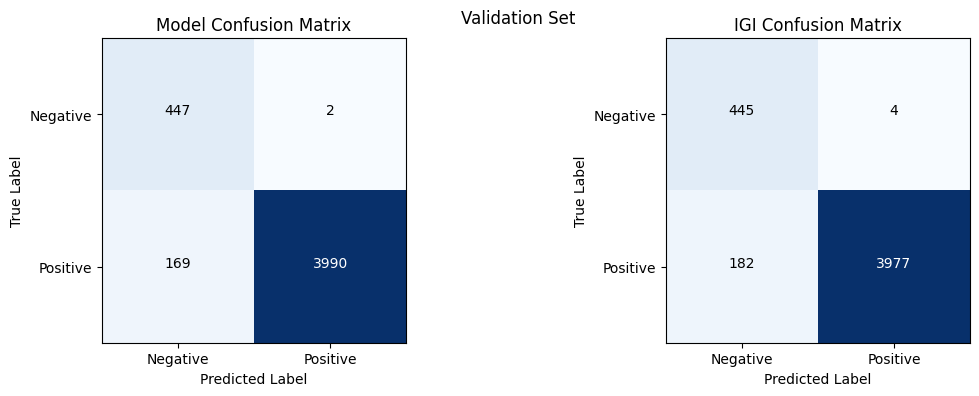

In [143]:

# Calculate the confusion matrix
cm1 = confusion_matrix(val_pred_df.groundtruth_label, matched_preds)
cm2 = confusion_matrix(val_pred_df.groundtruth_label, val_pred_df.encoded_igi_call)

# Define class labels (replace with your class labels)
class_labels = ["Negative", "Positive"]

# Create a heatmap of the confusion matrix
fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].imshow(cm1, interpolation='nearest', cmap=plt.cm.Blues)
axes[0].set_title("Model Confusion Matrix")
axes[0].set_xticks(np.arange(len(class_labels)))
axes[0].set_yticks(np.arange(len(class_labels)))
axes[0].set_xticklabels(class_labels)
axes[0].set_yticklabels(class_labels)

thresh = cm1.max() / 2.
for i, j in itertools.product(range(cm1.shape[0]), range(cm1.shape[1])):
    axes[0].text(j, i, format(cm1[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm1[i, j] > thresh else "black")

axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot the second confusion matrix
axes[1].imshow(cm2, interpolation='nearest', cmap=plt.cm.Blues)
axes[1].set_title("IGI Confusion Matrix")
axes[1].set_xticks(np.arange(len(class_labels)))
axes[1].set_yticks(np.arange(len(class_labels)))
axes[1].set_xticklabels(class_labels)
axes[1].set_yticklabels(class_labels)

thresh = cm2.max() / 2.
for i, j in itertools.product(range(cm2.shape[0]), range(cm2.shape[1])):
    axes[1].text(j, i, format(cm2[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm2[i, j] > thresh else "black")

axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

fig.tight_layout()
fig.suptitle('Validation Set')
plt.show()


In [144]:
val_pred_df.loc[:,'matched_pred'] = matched_preds
print('Model confusion matrix')
print(classification_report(val_pred_df.groundtruth_label, round(val_pred_df.matched_pred)))
print('IGI Model confusion matrix')
print(classification_report(val_pred_df.groundtruth_label, val_pred_df.encoded_igi_call))

Model confusion matrix
              precision    recall  f1-score   support

           0       0.73      1.00      0.84       449
           1       1.00      0.96      0.98      4159

    accuracy                           0.96      4608
   macro avg       0.86      0.98      0.91      4608
weighted avg       0.97      0.96      0.97      4608

IGI Model confusion matrix
              precision    recall  f1-score   support

           0       0.71      0.99      0.83       449
           1       1.00      0.96      0.98      4159

    accuracy                           0.96      4608
   macro avg       0.85      0.97      0.90      4608
weighted avg       0.97      0.96      0.96      4608



In [145]:
val_sample_df = (val_pred_df[['curve_idx','encoded_igi_call','matched_pred']]
 .merge(join_df[['curve_idx','sample_id', 'target','sample_type']]
        .loc[~join_df.target.isin(['MS2','RnaseP'])]
        .drop_duplicates(), how='inner', on='curve_idx')
 .groupby('sample_id')
 .filter(lambda x: len(x) > 1))

val_sample_df.loc[:,'sample_type'] = val_sample_df.sample_type.replace({'Negative Control (qPCR)': 0,
                                                                        'Human Normal Negative Control (Extraction)': 0,
                                                                        'Positive Control (qPCR)': 1})
val_sample_pred = (val_sample_df
 .groupby('sample_id')[['matched_pred','encoded_igi_call']]
 .apply('mean').reset_index())

print('Agreement rate between genes in model prediction is: ', (sum(val_sample_pred.matched_pred.isin([0,1]))/val_sample_pred.shape[0]))
print('Agreement rate between genes in IGI prediction is: ', (sum(val_sample_pred.encoded_igi_call.isin([0,1]))/val_sample_pred.shape[0]))

Agreement rate between genes in model prediction is:  0.9766355140186916
Agreement rate between genes in IGI prediction is:  0.985981308411215


In [146]:
diff_df = val_pred_df.loc[val_pred_df.encoded_igi_call != val_pred_df.matched_pred]
print('Number of different curves:', diff_df.shape[0])
diff_df.head()

Number of different curves: 79


,curve_idx,groundtruth_label,encoded_igi_call,outputs,matched_pred
285,103252,1,0,0.790140,1
409,30828,0,0,0.747156,1
421,43940,1,1,0.445443,0
424,322,1,1,0.478761,0
434,45626,1,1,0.586680,0


29135
86000
86384
128362


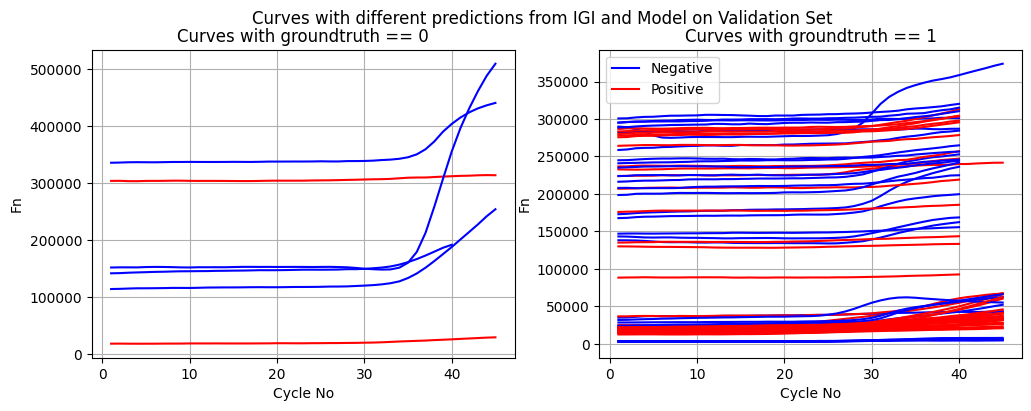

In [147]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
for idx in diff_df.curve_idx:
    df = diff_df[diff_df.curve_idx == idx]
    x = join_df.loc[join_df.curve_idx == idx, 'cycle_no']
    y = join_df.loc[join_df.curve_idx == idx, 'Fn']
    if df['groundtruth_label'].values == 0:    
        if df['matched_pred'].values == 0:
            print(idx)
            axes[0].plot(x,y, color = 'blue')
        else:
            axes[0].plot(x,y, color = 'red')
    else:
        if df['matched_pred'].values == 0:
            axes[1].plot(x,y, color = 'blue')
        else:
            axes[1].plot(x,y, color = 'red')

axes[0].set_xlabel('Cycle No')
axes[0].set_ylabel('Fn')
axes[0].set_title('Curves with groundtruth == 0')
axes[0].grid()

axes[1].plot(1,1,color = 'blue', label = 'Negative')
axes[1].plot(1,1,color = 'red', label = 'Positive')
axes[1].set_xlabel('Cycle No')
axes[1].set_ylabel('Fn')
axes[1].set_title('Curves with groundtruth == 1')
axes[1].grid()
axes[1].legend()
fig.suptitle('Curves with different predictions from IGI and Model on Validation Set')
plt.show()

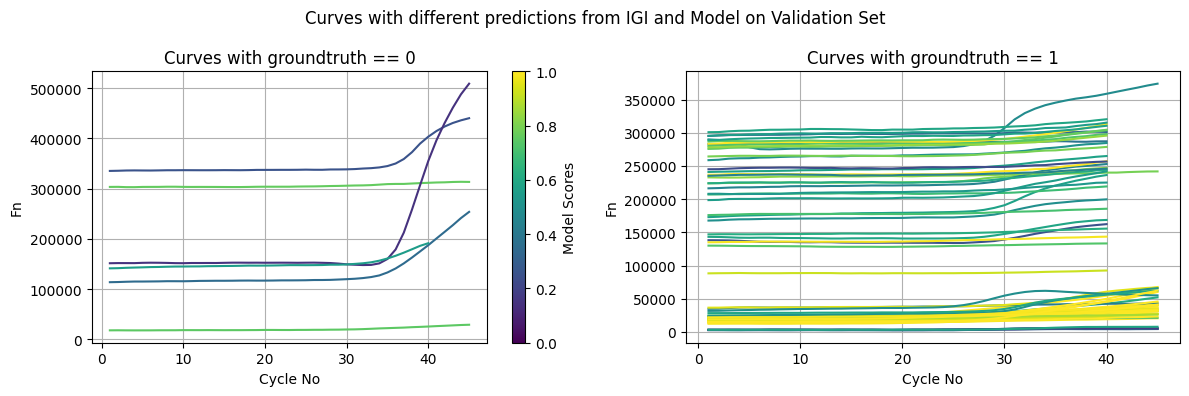

In [148]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
cmap = plt.get_cmap('viridis')  # You can choose a different colormap
color_vals = diff_df.outputs.to_list()
curve_ids = diff_df.curve_idx.to_list()
for i in range(diff_df.shape[0]): 
    x = join_df.loc[join_df.curve_idx == curve_ids[i],'cycle_no']
    y = join_df.loc[join_df.curve_idx == curve_ids[i],'Fn']

    color1 = cmap(color_vals[i])
    if diff_df.loc[diff_df.curve_idx == curve_ids[i], 'groundtruth_label'].values == 0:
        axes[0].plot(x,y, color = color1, label = 'Model predicts negative')
    else:
        axes[1].plot(x,y, color = color1, label = 'Model predicts negative')
    
axes[0].set_xlabel('Cycle No')
axes[0].set_ylabel('Fn')
axes[0].set_title('Curves with groundtruth == 0')
axes[0].grid()

axes[1].set_xlabel('Cycle No')
axes[1].set_ylabel('Fn')
axes[1].set_title('Curves with groundtruth == 1')
axes[1].grid()

# Customize the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, label='Model Scores', ax = axes[0])
fig.suptitle('Curves with different predictions from IGI and Model on Validation Set')
plt.tight_layout()
plt.show()

In [ ]:
# Define a color palette or dictionary
color_dict = {'RnaseP': 'red', 'MS2': 'green', 'N gene': 'blue'}

# Create a Matplotlib figure and axis
fig, ax = plt.subplots()

# Iterate through groups and plot lines with colors
for group, group_data in df.groupby('Group'):
    ax.plot(group_data['X'], group_data['Y'], label=group, color=color_dict[group])


## Test set

In [113]:
igi_recall = recall_score(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)
igi_precision = precision_score(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)
igi_tn = sum((test_pred_df.groundtruth_label == test_pred_df.encoded_igi_call) & (test_pred_df.encoded_igi_call == 0))

print('IGI precision score:', igi_precision)
print('IGI recall score:', igi_recall)
print('IGI true negatives:', igi_tn)

IGI precision score: 1.0
IGI recall score: 0.955277928661959
IGI true negatives: 621


In [114]:
pred = 1*(test_pred_df.outputs >= best_threshold)
print('Test set')
print('Number of false negatives:', sum((test_pred_df.groundtruth_label != 0) & (test_pred_df.groundtruth_label != pred)))
print('Model test precision:', precision_score(test_pred_df.groundtruth_label, pred))
print('Mdel test recall:', recall_score(test_pred_df.groundtruth_label, pred))

Test set
Number of false negatives: 154
Model test precision: 0.996658622609987
Mdel test recall: 0.9721166032953105


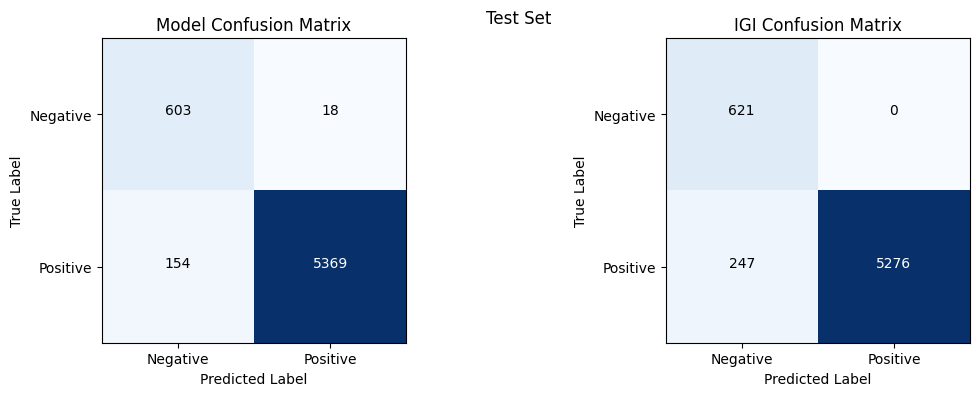

In [115]:
matched_preds = 1*(test_pred_df.outputs >= best_threshold)
# Calculate the confusion matrix
cm1 = confusion_matrix(test_pred_df.groundtruth_label, matched_preds)
cm2 = confusion_matrix(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)

# Define class labels (replace with your class labels)
class_labels = ["Negative", "Positive"]

# Create a heatmap of the confusion matrix
fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].imshow(cm1, interpolation='nearest', cmap=plt.cm.Blues)
axes[0].set_title("Model Confusion Matrix")
axes[0].set_xticks(np.arange(len(class_labels)))
axes[0].set_yticks(np.arange(len(class_labels)))
axes[0].set_xticklabels(class_labels)
axes[0].set_yticklabels(class_labels)

thresh = cm1.max() / 2.
for i, j in itertools.product(range(cm1.shape[0]), range(cm1.shape[1])):
    axes[0].text(j, i, format(cm1[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm1[i, j] > thresh else "black")

axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot the second confusion matrix
axes[1].imshow(cm2, interpolation='nearest', cmap=plt.cm.Blues)
axes[1].set_title("IGI Confusion Matrix")
axes[1].set_xticks(np.arange(len(class_labels)))
axes[1].set_yticks(np.arange(len(class_labels)))
axes[1].set_xticklabels(class_labels)
axes[1].set_yticklabels(class_labels)

thresh = cm2.max() / 2.
for i, j in itertools.product(range(cm2.shape[0]), range(cm2.shape[1])):
    axes[1].text(j, i, format(cm2[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm2[i, j] > thresh else "black")

axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
fig.suptitle('Test Set')
plt.show()


In [116]:
test_pred_df.loc[:,['matched_pred']] = matched_preds
print('Model confusion matrix')
print(classification_report(test_pred_df.groundtruth_label, round(test_pred_df.matched_pred)))
print('IGI confusion matrix')
print(classification_report(test_pred_df.groundtruth_label, round(test_pred_df.encoded_igi_call)))

Model confusion matrix
              precision    recall  f1-score   support

           0       0.80      0.97      0.88       621
           1       1.00      0.97      0.98      5523

    accuracy                           0.97      6144
   macro avg       0.90      0.97      0.93      6144
weighted avg       0.98      0.97      0.97      6144

IGI confusion matrix
              precision    recall  f1-score   support

           0       0.72      1.00      0.83       621
           1       1.00      0.96      0.98      5523

    accuracy                           0.96      6144
   macro avg       0.86      0.98      0.91      6144
weighted avg       0.97      0.96      0.96      6144



In [117]:
test_sample_df = (test_pred_df[['curve_idx','encoded_igi_call','matched_pred']]
 .merge(join_df[['curve_idx','sample_id', 'target','sample_type']]
        .loc[~join_df.target.isin(['MS2','RnaseP'])]
        .drop_duplicates(), how='inner', on='curve_idx')
 .groupby('sample_id')
 .filter(lambda x: len(x) > 1))

test_sample_df.loc[:,'sample_type'] = test_sample_df.sample_type.replace({'Negative Control (qPCR)': 0,
                                                                        'Human Normal Negative Control (Extraction)': 0,
                                                                        'Positive Control (qPCR)': 1})
test_sample_pred = (test_sample_df
 .groupby('sample_id')[['matched_pred','encoded_igi_call']]
 .apply('mean').reset_index())

print('Agreement rate between genes in Model prediction is: ', (sum(test_sample_pred.matched_pred.isin([0,1]))/test_sample_pred.shape[0]))
print('Agreement rate between genes in IGI prediction is: ', (sum(test_sample_pred.encoded_igi_call.isin([0,1]))/test_sample_pred.shape[0]))

Agreement rate between genes in Model prediction is:  0.9793103448275862
Agreement rate between genes in IGI prediction is:  0.9896551724137931


In [118]:
diff_df = test_pred_df.loc[test_pred_df.encoded_igi_call != test_pred_df.matched_pred]
print('Number of different curves:', diff_df.shape[0])
diff_df.head()

Number of different curves: 181


,curve_idx,groundtruth_label,encoded_igi_call,outputs,matched_pred
18,115381,0,0,0.967775,1
48,60085,0,0,0.932045,1
142,27237,0,0,0.941102,1
145,27238,0,0,0.936727,1
148,27261,0,0,0.934831,1


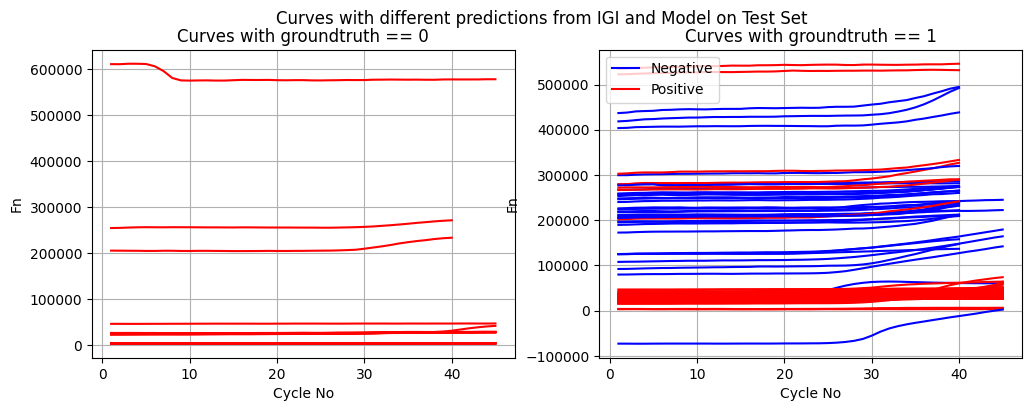

In [119]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
for idx in diff_df.curve_idx:
    df = diff_df[diff_df.curve_idx == idx]
    x = join_df.loc[join_df.curve_idx == idx, 'cycle_no']
    y = join_df.loc[join_df.curve_idx == idx, 'Fn']
    if df['groundtruth_label'].values == 0:    
        if df['matched_pred'].values == 0:
            print(idx)
            axes[0].plot(x,y, color = 'blue')
        else:
            axes[0].plot(x,y, color = 'red')
    else:
        if df['matched_pred'].values == 0:
            axes[1].plot(x,y, color = 'blue')
        else:
            axes[1].plot(x,y, color = 'red')

axes[0].set_xlabel('Cycle No')
axes[0].set_ylabel('Fn')
axes[0].set_title('Curves with groundtruth == 0')
axes[0].grid()

axes[1].plot(1,1,color = 'blue', label = 'Negative')
axes[1].plot(1,1,color = 'red', label = 'Positive')
axes[1].set_xlabel('Cycle No')
axes[1].set_ylabel('Fn')
axes[1].set_title('Curves with groundtruth == 1')
axes[1].grid()
axes[1].legend()
fig.suptitle('Curves with different predictions from IGI and Model on Test Set')
plt.show()

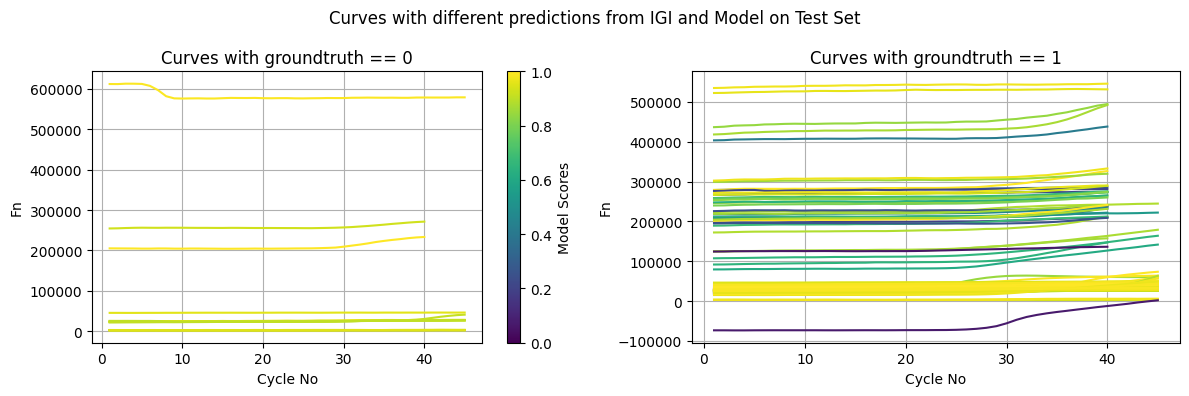

In [120]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
cmap = plt.get_cmap('viridis')  # You can choose a different colormap
color_vals = diff_df.outputs.to_list()
curve_ids = diff_df.curve_idx.to_list()
for i in range(diff_df.shape[0]): 
    x = join_df.loc[join_df.curve_idx == curve_ids[i],'cycle_no']
    y = join_df.loc[join_df.curve_idx == curve_ids[i],'Fn']

    color1 = cmap(color_vals[i])
    if diff_df.loc[diff_df.curve_idx == curve_ids[i], 'groundtruth_label'].values == 0:
        axes[0].plot(x,y, color = color1, label = 'Model predicts negative')
    else:
        axes[1].plot(x,y, color = color1, label = 'Model predicts negative')
    
axes[0].set_xlabel('Cycle No')
axes[0].set_ylabel('Fn')
axes[0].set_title('Curves with groundtruth == 0')
axes[0].grid()

axes[1].set_xlabel('Cycle No')
axes[1].set_ylabel('Fn')
axes[1].set_title('Curves with groundtruth == 1')
axes[1].grid()

# Customize the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, label='Model Scores', ax = axes[0])
fig.suptitle('Curves with different predictions from IGI and Model on Test Set')
plt.tight_layout()
plt.show()

### Other genes validation